# 웹 검색 모듈 추가

**절차**

1. Naive RAG 수행
2. 검색된 문서에 대한 관련성 체크(Groundedness Check)
3. (이번 튜토리얼) Web Search 추가

**참고**

- 이전 튜토리얼에서 확장된 내용이므로, 겹치는 부분이 있을 수 있습니다. 부족한 설명은 이전 튜토리얼을 참고해주세요.

![langgraph-web-search](assets/langgraph-web-search.png)

## 환경 설정

In [1]:
# !pip install -U langchain-teddynote

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv()

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("CH17-LangGraph-Structures")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH17-LangGraph-Structures


## 기본 PDF 기반 Retrieval Chain 생성

여기서는 PDF 문서를 기반으로 Retrieval Chain 을 생성합니다. 가장 단순한 구조의 Retrieval Chain 입니다.

단, LangGraph 에서는 Retirever 와 Chain 을 따로 생성합니다. 그래야 각 노드별로 세부 처리를 할 수 있습니다.

**참고**

- 이전 튜토리얼에서 다룬 내용이므로, 자세한 설명은 생략합니다.

In [3]:
from rag.pdf import PDFRetrievalChain

# PDF 문서를 로드합니다.
pdf = PDFRetrievalChain(["data/SPRI_AI_Brief_2023년12월호_F.pdf"]).create_chain()

# retriever와 chain을 생성합니다.
pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

## State 정의

`State`: Graph 의 노드와 노드 간 공유하는 상태를 정의합니다.

일반적으로 `TypedDict` 형식을 사용합니다.

이번에는 상태(State)에 관련성(relevance) 체크 결과를 추가합니다.

In [4]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages


# GraphState 상태 정의
class GraphState(TypedDict):
    question: Annotated[str, "Question"]  # 질문
    context: Annotated[str, "Context"]  # 문서의 검색 결과
    answer: Annotated[str, "Answer"]  # 답변
    messages: Annotated[list, add_messages]  # 메시지(누적되는 list)
    relevance: Annotated[str, "Relevance"]  # 관련성

## 노드(Node) 정의

- `Nodes`: 각 단계를 처리하는 노드입니다. 보통은 Python 함수로 구현합니다. 입력과 출력이 상태(State) 값입니다.
  
**참고**  

- `State`를 입력으로 받아 정의된 로직을 수행한 후 업데이트된 `State`를 반환합니다.

In [5]:
from langchain_openai import ChatOpenAI
from langchain_teddynote.evaluator import GroundednessChecker
from langchain_teddynote.messages import messages_to_history
from rag.utils import format_docs


# 문서 검색 노드
def retrieve_document(state: GraphState) -> GraphState:
    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 문서에서 검색하여 관련성 있는 문서를 찾습니다.
    retrieved_docs = pdf_retriever.invoke(latest_question)

    # 검색된 문서를 형식화합니다.(프롬프트 입력으로 넣어주기 위함)
    retrieved_docs = format_docs(retrieved_docs)

    # 검색된 문서를 context 키에 저장합니다.
    return GraphState(context=retrieved_docs)


# 답변 생성 노드
def llm_answer(state: GraphState) -> GraphState:
    # 질문을 상태에서 가져옵니다.
    latest_question = state["question"]

    # 검색된 문서를 상태에서 가져옵니다.
    context = state["context"]

    # 체인을 호출하여 답변을 생성합니다.
    response = pdf_chain.invoke(
        {
            "question": latest_question,
            "context": context,
            "chat_history": messages_to_history(state["messages"]),
        }
    )
    # 생성된 답변, (유저의 질문, 답변) 메시지를 상태에 저장합니다.
    return GraphState(
        answer=response, messages=[("user", latest_question), ("assistant", response)]
    )


# 관련성 체크 노드
def relevance_check(state: GraphState) -> GraphState:
    # 관련성 평가기를 생성합니다.
    question_answer_relevant = GroundednessChecker(
        llm=ChatOpenAI(model="gpt-4o-mini", temperature=0), target="question-retrieval"
    ).create()

    # 관련성 체크를 실행("yes" or "no")
    response = question_answer_relevant.invoke(
        {"question": state["question"], "context": state["context"]}
    )

    print("==== [RELEVANCE CHECK] ====")
    print(response.score)

    # 참고: 여기서의 관련성 평가기는 각자의 Prompt 를 사용하여 수정할 수 있습니다. 여러분들의 Groundedness Check 를 만들어 사용해 보세요!
    return GraphState(relevance=response.score)


# 관련성 체크하는 함수(router)
def is_relevant(state: GraphState) -> GraphState:
    if state["relevance"] == "yes":
        return "relevant"
    else:
        return "not relevant"

## 검색 노드 추가

이번에는 `TavilySearch` 도구를 사용하여 Web Search 를 수행합니다.

아래는 `TavilySearch` 도구를 사용한 예제입니다.

In [6]:
from langchain_teddynote.tools.tavily import TavilySearch

# 검색 도구 생성
tavily_tool = TavilySearch()

search_query = "2024년 노벨 문학상 수상자는?"

# 다양한 파라미터를 사용한 검색 예제
search_result = tavily_tool.search(
    query=search_query,  # 검색 쿼리
    max_results=3,  # 최대 검색 결과
    format_output=True,  # 결과 포맷팅
)

# 검색 결과 출력
print(search_result)

['<document><title>한국 작가 한강, 2024년 노벨 문학상 수상 상세보기|공지사항</title><url>https://overseas.mofa.go.kr/se-ko/brd/m_7977/view.do?seq=1345639</url><content>**바로가기 메뉴** 본문 바로가기 주메뉴 바로가기 * 대사관 활동 ## 한국 작가 한강, 2024년 노벨 문학상 수상 :   주 스웨덴 대사관 스웨덴 한림원은 10.10(목) 2024년 노벨 문학상 수상자로 한국 작가 한강을 선정했습니다. 한국인 최초 노벨문학상 수상이자 아시아 여성 작가로서 최초 수상이라는 의미가 있으며, 금번 수상을 통해 한국 문학의 독창성과 깊이가 전세계적으로 인정받고 각인시키는 계기가 될 것으로 기대합니다. 한강 작가가 초청되었던 금년 3월 스웨덴 스톨혹름 북콘서트와 우메오 국제문학축제에서는 한강 작가의 최신작 ‘작별하지 않는다’에 대한 스웨덴 문학애호가들의 높은 관심과 애정을 확인할 수 있었습니다. 한국 문화 전반에 대한 전세계적인 열풍 속에서 북유럽 지역에서도 한국 음식, 드라마, 뷰티, 대중가요 등 K-콘텐츠에 대한 인기가 높아지고 있습니다. 한강 작가의 노벨문학상 수상을 계기로 한국 문학이 북유럽과 전세계로 뻗어나갈 수 있도록 우리 대사관과 문화원 또한 노력하겠습니다. 주스웨덴 대한민국 대사관</content><raw>**바로가기 메뉴**\n[본문 바로가기](#contents)\n[주메뉴 바로가기](#gnb)\n\n\n\n\n\n**알림·소식**\n\n* [공지사항](/se-ko/brd/m_7977/list.do "현재 페이지")\n* [다가오는 행사](/se-ko/brd/m_7978/list.do)\n* [대사관 활동](/se-ko/brd/m_7980/list.do)\n\n## 공지사항\n\n2. 알림·소식\n3. 공지사항\n\n* **글자크기**\n\n## 한국 작가 한강, 2024년 노벨 문학상 수상\n\n작성자\n:   주 스웨덴 대사관\n\n작성일\n:   202

검색 노드로 패키징하여 추가합니다. (함수 생성)

In [7]:
# Web Search 노드
def web_search(state: GraphState) -> GraphState:
    # 검색 도구 생성
    tavily_tool = TavilySearch()

    search_query = state["question"]

    # 다양한 파라미터를 사용한 검색 예제
    search_result = tavily_tool.search(
        query=search_query,  # 검색 쿼리
        topic="general",  # 일반 주제
        max_results=6,  # 최대 검색 결과
        format_output=True,  # 결과 포맷팅
    )

    return {"context": search_result}

## Edges

- `Edges`: 현재 `State`를 기반으로 다음에 실행할 `Node`를 결정하는 Python 함수.

일반 엣지, 조건부 엣지 등이 있습니다.

In [8]:
from langgraph.graph import END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

# 그래프 정의
workflow = StateGraph(GraphState)

# 노드 추가
workflow.add_node("retrieve", retrieve_document)
workflow.add_node("relevance_check", relevance_check)
workflow.add_node("llm_answer", llm_answer)

# Web Search 노드 추가
workflow.add_node("web_search", web_search)

# 엣지 추가
workflow.add_edge("retrieve", "relevance_check")  # 검색 -> 관련성 체크


# 조건부 엣지를 추가합니다.
workflow.add_conditional_edges(
    "relevance_check",  # 관련성 체크 노드에서 나온 결과를 is_relevant 함수에 전달합니다.
    is_relevant,
    {
        "relevant": "llm_answer",  # 관련성이 있으면 답변을 생성합니다.
        "not relevant": "web_search",  # 관련성이 없으면 웹 검색을 수행합니다.
    },
)

workflow.add_edge("web_search", "llm_answer")  # 검색 -> 답변
workflow.add_edge("llm_answer", END)  # 답변 -> 종료

# 그래프 진입점 설정
workflow.set_entry_point("retrieve")

# 체크포인터 설정
memory = MemorySaver()

# 그래프 컴파일
app = workflow.compile(checkpointer=memory)

컴파일한 그래프를 시각화 합니다.

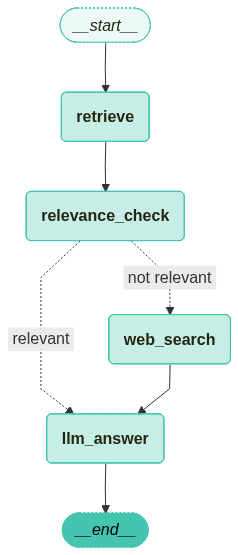

In [9]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app)

## 그래프 실행

- `config` 파라미터는 그래프 실행 시 필요한 설정 정보를 전달합니다.
- `recursion_limit`: 그래프 실행 시 재귀 최대 횟수를 설정합니다.
- `inputs`: 그래프 실행 시 필요한 입력 정보를 전달합니다.

검색 결과의 `relevance_check` 가 실패할 경우, 검색을 수행하여 웹 검색 결과를 제공합니다.

In [10]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph, invoke_graph, random_uuid


# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": random_uuid()})

# 질문 입력
inputs = GraphState(question="2024년 노벨 문학상 수상자는?")

# 그래프 실행
invoke_graph(app, inputs, config, ["relevance_check", "llm_answer"])

==== [RELEVANCE CHECK] ====
no

🔄 Node: relevance_check 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
relevance:
no

🔄 Node: llm_answer 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
answer:
2024년 노벨 문학상 수상자는 한강 작가입니다. 그녀는 한국인 최초이자 아시아 여성 최초로 이 상을 수상하였습니다.

**Source**
- [2024년 노벨문학상 수상 작가, 한강 - 문학과지성사](https://moonji.com/38049/) 
- [2024 노벨문학상 수상자로 한강 작가 선정!!! : 네이버 블로그](https://blog.naver.com/jinzao77/223617501714?viewType=pc)
- [영상] “너무 추웠던 9년”…봄으로 가는 한강에게 노벨문학상이 왔다](https://www.hani.co.kr/arti/culture/culture_general/1161999.html)
- [속보] 소설가 한강 노벨 문학상 수상..한국 작가 최초 수상 쾌거](https://www.youtube.com/watch?v=FsMuWl5LYNA)
('user', '2024년 노벨 문학상 수상자는?')
('assistant', '2024년 노벨 문학상 수상자는 한강 작가입니다. 그녀는 한국인 최초이자 아시아 여성 최초로 이 상을 수상하였습니다.\n\n**Source**\n- [2024년 노벨문학상 수상 작가, 한강 - 문학과지성사](https://moonji.com/38049/) \n- [2024 노벨문학상 수상자로 한강 작가 선정!!! : 네이버 블로그](https://blog.naver.com/jinzao77/223617501714?viewType=pc)\n- [영상] “너무 추웠던 9년”…봄으로 가는 한강에게 노벨문학상이 왔다](https://www.hani.co.kr/arti

In [11]:
# 그래프 스트리밍 출력
stream_graph(app, inputs, config, ["relevance_check", "llm_answer"])


🔄 Node: relevance_check 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"score":"no"}==== [RELEVANCE CHECK] ====
no

🔄 Node: llm_answer 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
2024년 노벨 문학상 수상자는 한강 작가입니다. 그녀는 한국인 최초이자 아시아 여성 최초로 이 상을 수상하였습니다.

**Source**
- [2024년 노벨문학상 수상 작가, 한강 - 문학과지성사](https://moonji.com/38049/)
- [2024 노벨문학상 수상자로 한강 작가 선정!!! : 네이버 블로그](https://blog.naver.com/jinzao77/223617501714?viewType=pc)
- [영상] “너무 추웠던 9년”…봄으로 가는 한강에게 노벨문학상이 왔다](https://www.hani.co.kr/arti/culture/culture_general/1161999.html)
- [속보] 소설가 한강 노벨 문학상 수상..한국 작가 최초 수상 쾌거](https://www.youtube.com/watch?v=FsMuWl5LYNA)

In [12]:
# 최종 출력 확인
outputs = app.get_state(config).values

print(f'Question: {outputs["question"]}')
print("===" * 20)
print(f'Answer:\n{outputs["answer"]}')

Question: 2024년 노벨 문학상 수상자는?
Answer:
2024년 노벨 문학상 수상자는 한강 작가입니다. 그녀는 한국인 최초이자 아시아 여성 최초로 이 상을 수상하였습니다.

**Source**
- [2024년 노벨문학상 수상 작가, 한강 - 문학과지성사](https://moonji.com/38049/)
- [2024 노벨문학상 수상자로 한강 작가 선정!!! : 네이버 블로그](https://blog.naver.com/jinzao77/223617501714?viewType=pc)
- [영상] “너무 추웠던 9년”…봄으로 가는 한강에게 노벨문학상이 왔다](https://www.hani.co.kr/arti/culture/culture_general/1161999.html)
- [속보] 소설가 한강 노벨 문학상 수상..한국 작가 최초 수상 쾌거](https://www.youtube.com/watch?v=FsMuWl5LYNA)
